# SE 敏感性试验：上层外区非绝热加热 Q 对次级环流的影响

**数据**: Thompson 方案 (cm1out_thompson.nc), t = 72 h  
**修改区域**: z ∈ [10, 17.5] km, r > 50 km  
**试验组**: CTRL | Q×0.5 | Q×0.8 | Q×1.2 | Q×1.5

---
## 平滑处理方法

### 问题
在修改区域边界处，若 Q 场不连续，其导数 $\partial Q/\partial r$ 和 $\partial Q/\partial z$ 会产生尖峰，
通过 SE 方程的热力强迫项 $F_\text{thermal} = g\frac{\partial(\chi^2 Q)}{\partial r} + \frac{\partial(C\chi^2 Q)}{\partial z}$ 
将虚假信号注入求解器，导致 SOR 解出现 Gibbs 型波纹。

### 方案: 双曲正切 (tanh) 锥形过渡

构造三维平滑权重场 $w(r,z)$：

$$w_\text{lower}(z) = \frac{1}{2}\left[1 + \tanh\left(\frac{z - z_\text{min}}{\delta_z}\right)\right]$$
$$w_\text{upper}(z) = \frac{1}{2}\left[1 + \tanh\left(\frac{z_\text{max} - z}{\delta_z}\right)\right]$$
$$w_\text{radial}(r) = \frac{1}{2}\left[1 + \tanh\left(\frac{r - r_\text{min}}{\delta_r}\right)\right]$$
$$w(r,z) = w_\text{lower} \cdot w_\text{upper} \cdot w_\text{radial}$$

修改 Q 场：$Q_\text{new} = Q_\text{orig} \times [1 + (f - 1) \times w(r,z)]$

**参数设置**:
- 垂直过渡半宽 $\delta_z = 0.5$ km ($\approx 1.2\Delta z$)
- 径向过渡半宽 $\delta_r = 8.0$ km ($\approx 0.67\Delta r$)

### 为什么 tanh 能避免虚假波纹？

1. **C∞ 光滑**: tanh 函数的所有阶导数均连续，因此 $Q_\text{new}$ 在边界处任意阶可导
2. **导数连续**: 热力强迫项依赖 $\partial Q/\partial r$ 和 $\partial Q/\partial z$，tanh 保证这些导数在过渡区光滑变化
3. **无 Gibbs 现象**: 光滑的源项 → 光滑的椭圆方程解 → 无虚假振荡
4. **物理一致性**: 过渡区宽度与实际大气过程的空间尺度匹配

**当前实现的 taper 统计**: 258 内部点 (taper>0.95), 114 过渡点, 853 外部点

---
## 1. 次级环流风场对比 (U_se / W_se)

绿色虚线: 切向风等值线 (间隔 20 m/s) | 黄色阴影: Q 修改区域

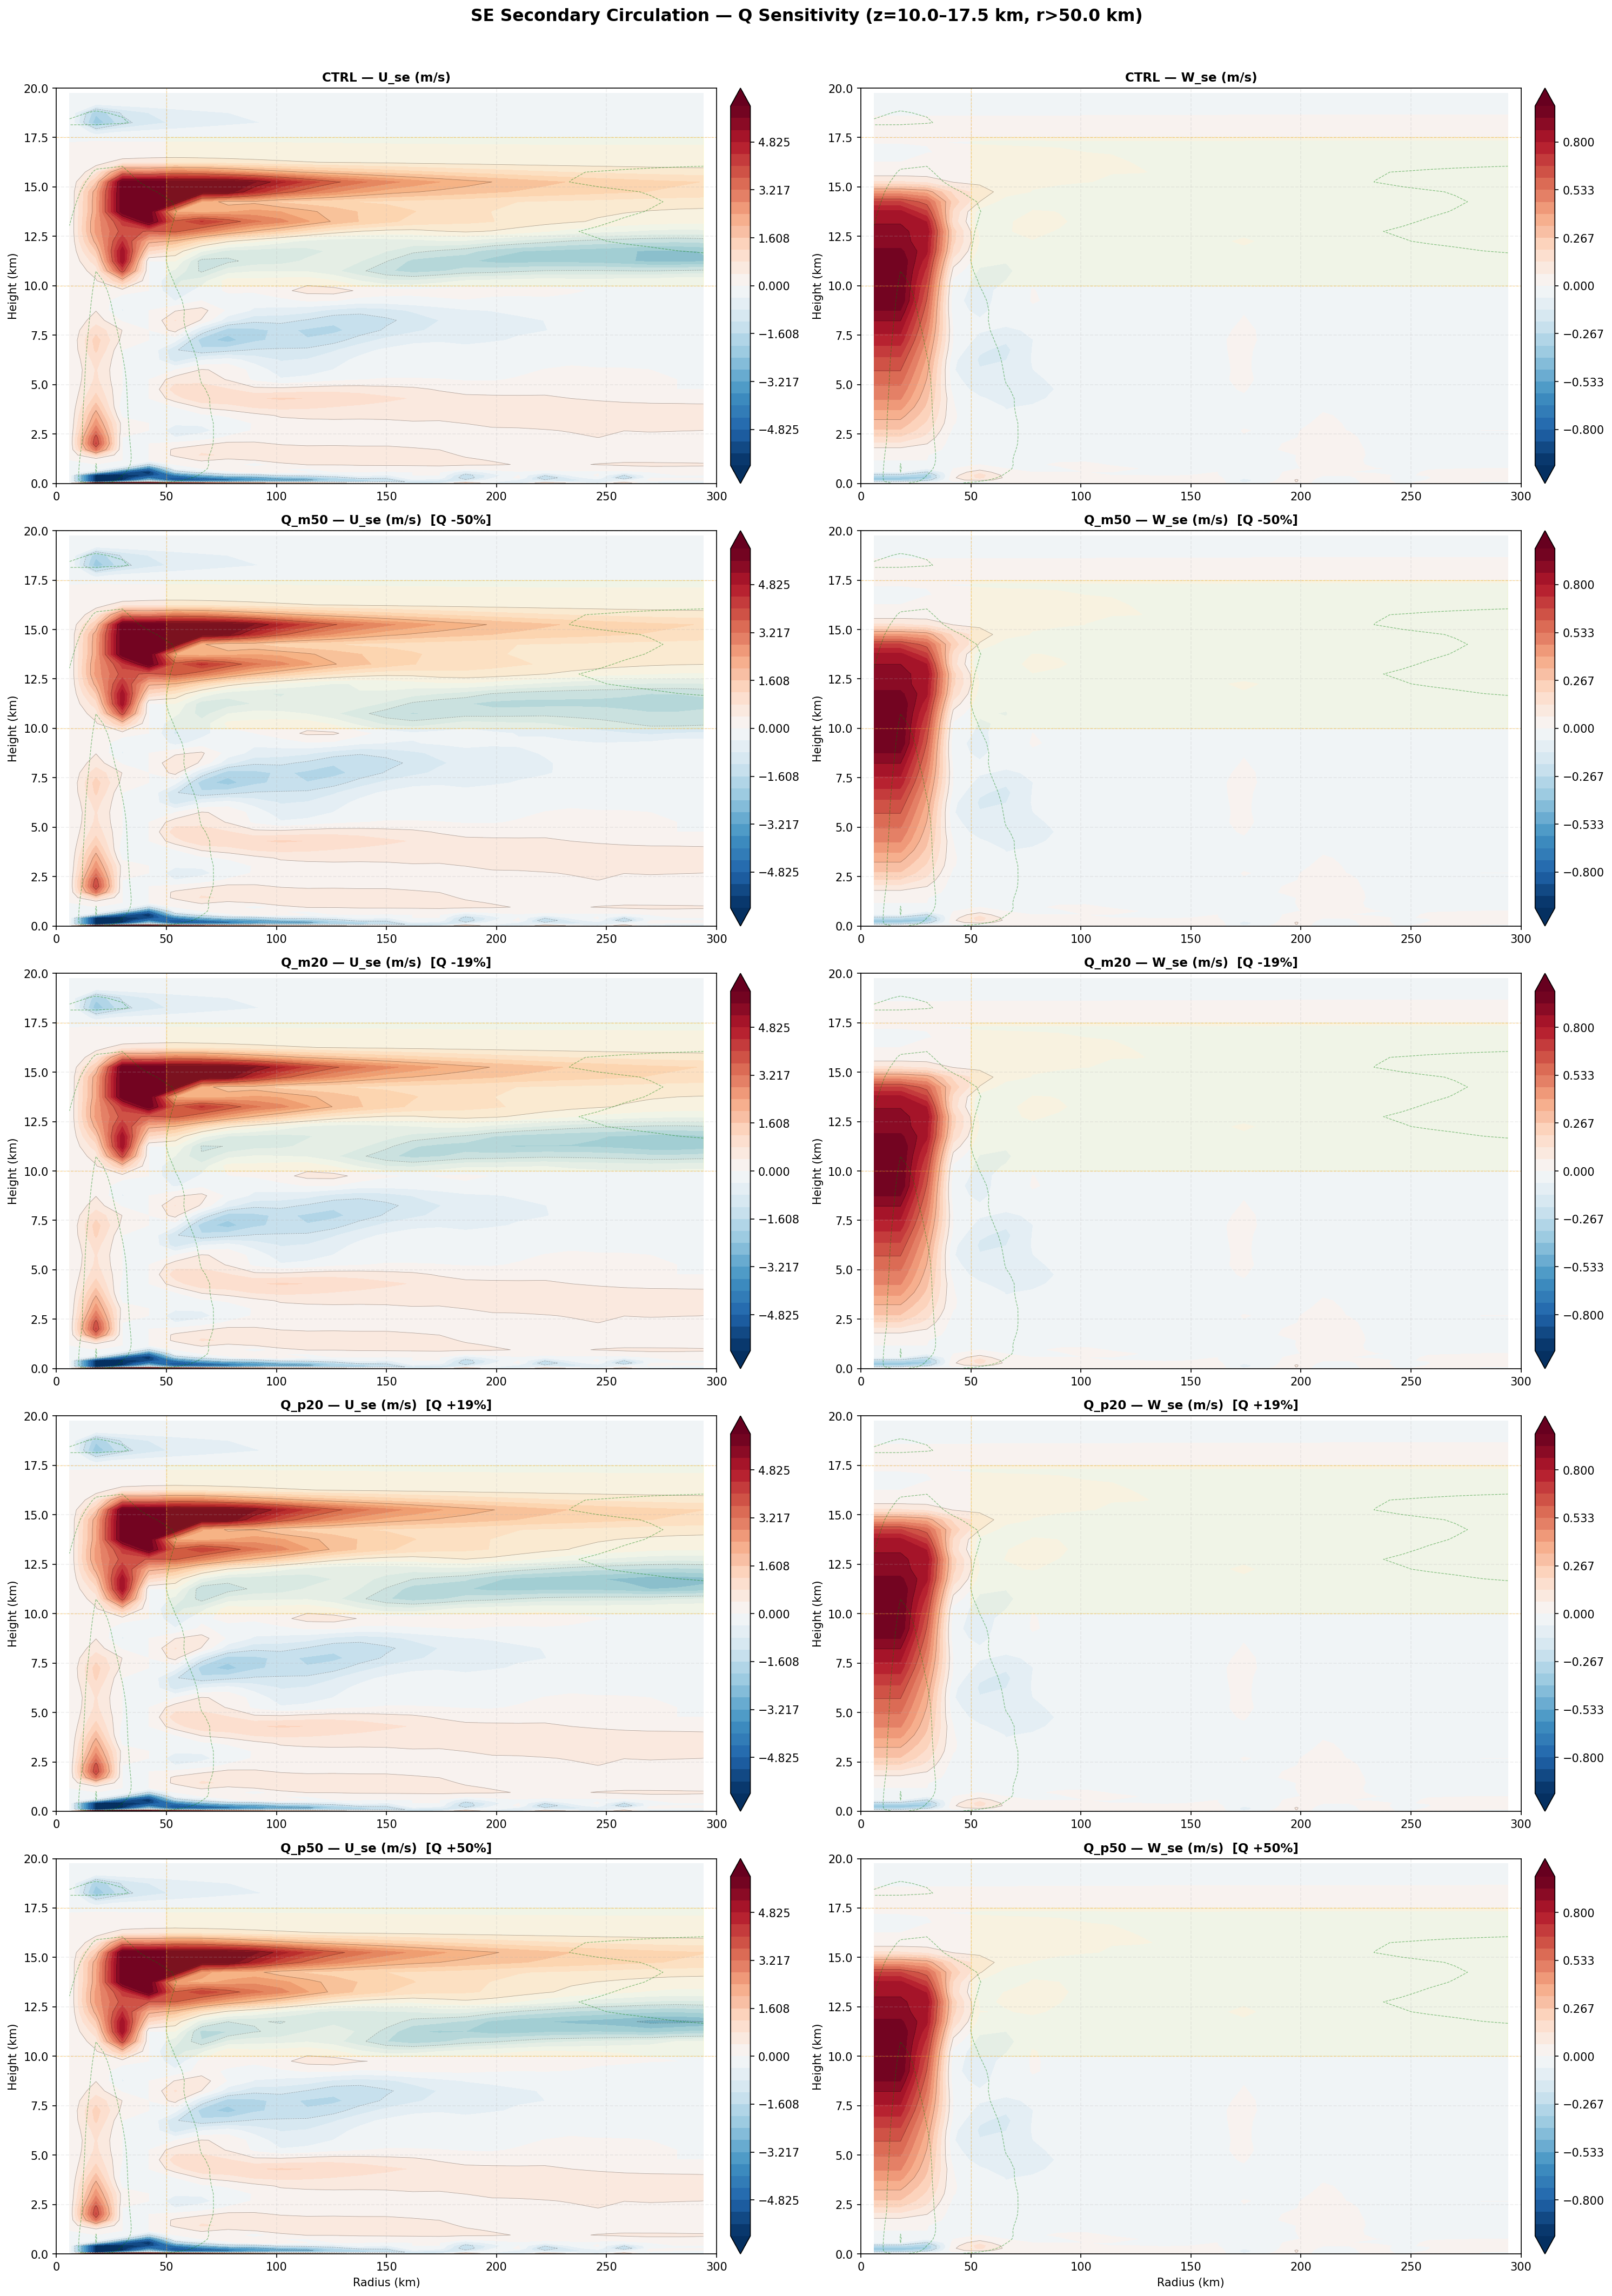

In [2]:
from IPython.display import Image, display
display(Image(filename='../output/figures/se_Q_sensitivity/se_wind_comparison.png'))

---
## 2. ΔU_se 差值图 (各试验 − CTRL)

橙色虚线: Q 修改区域边界

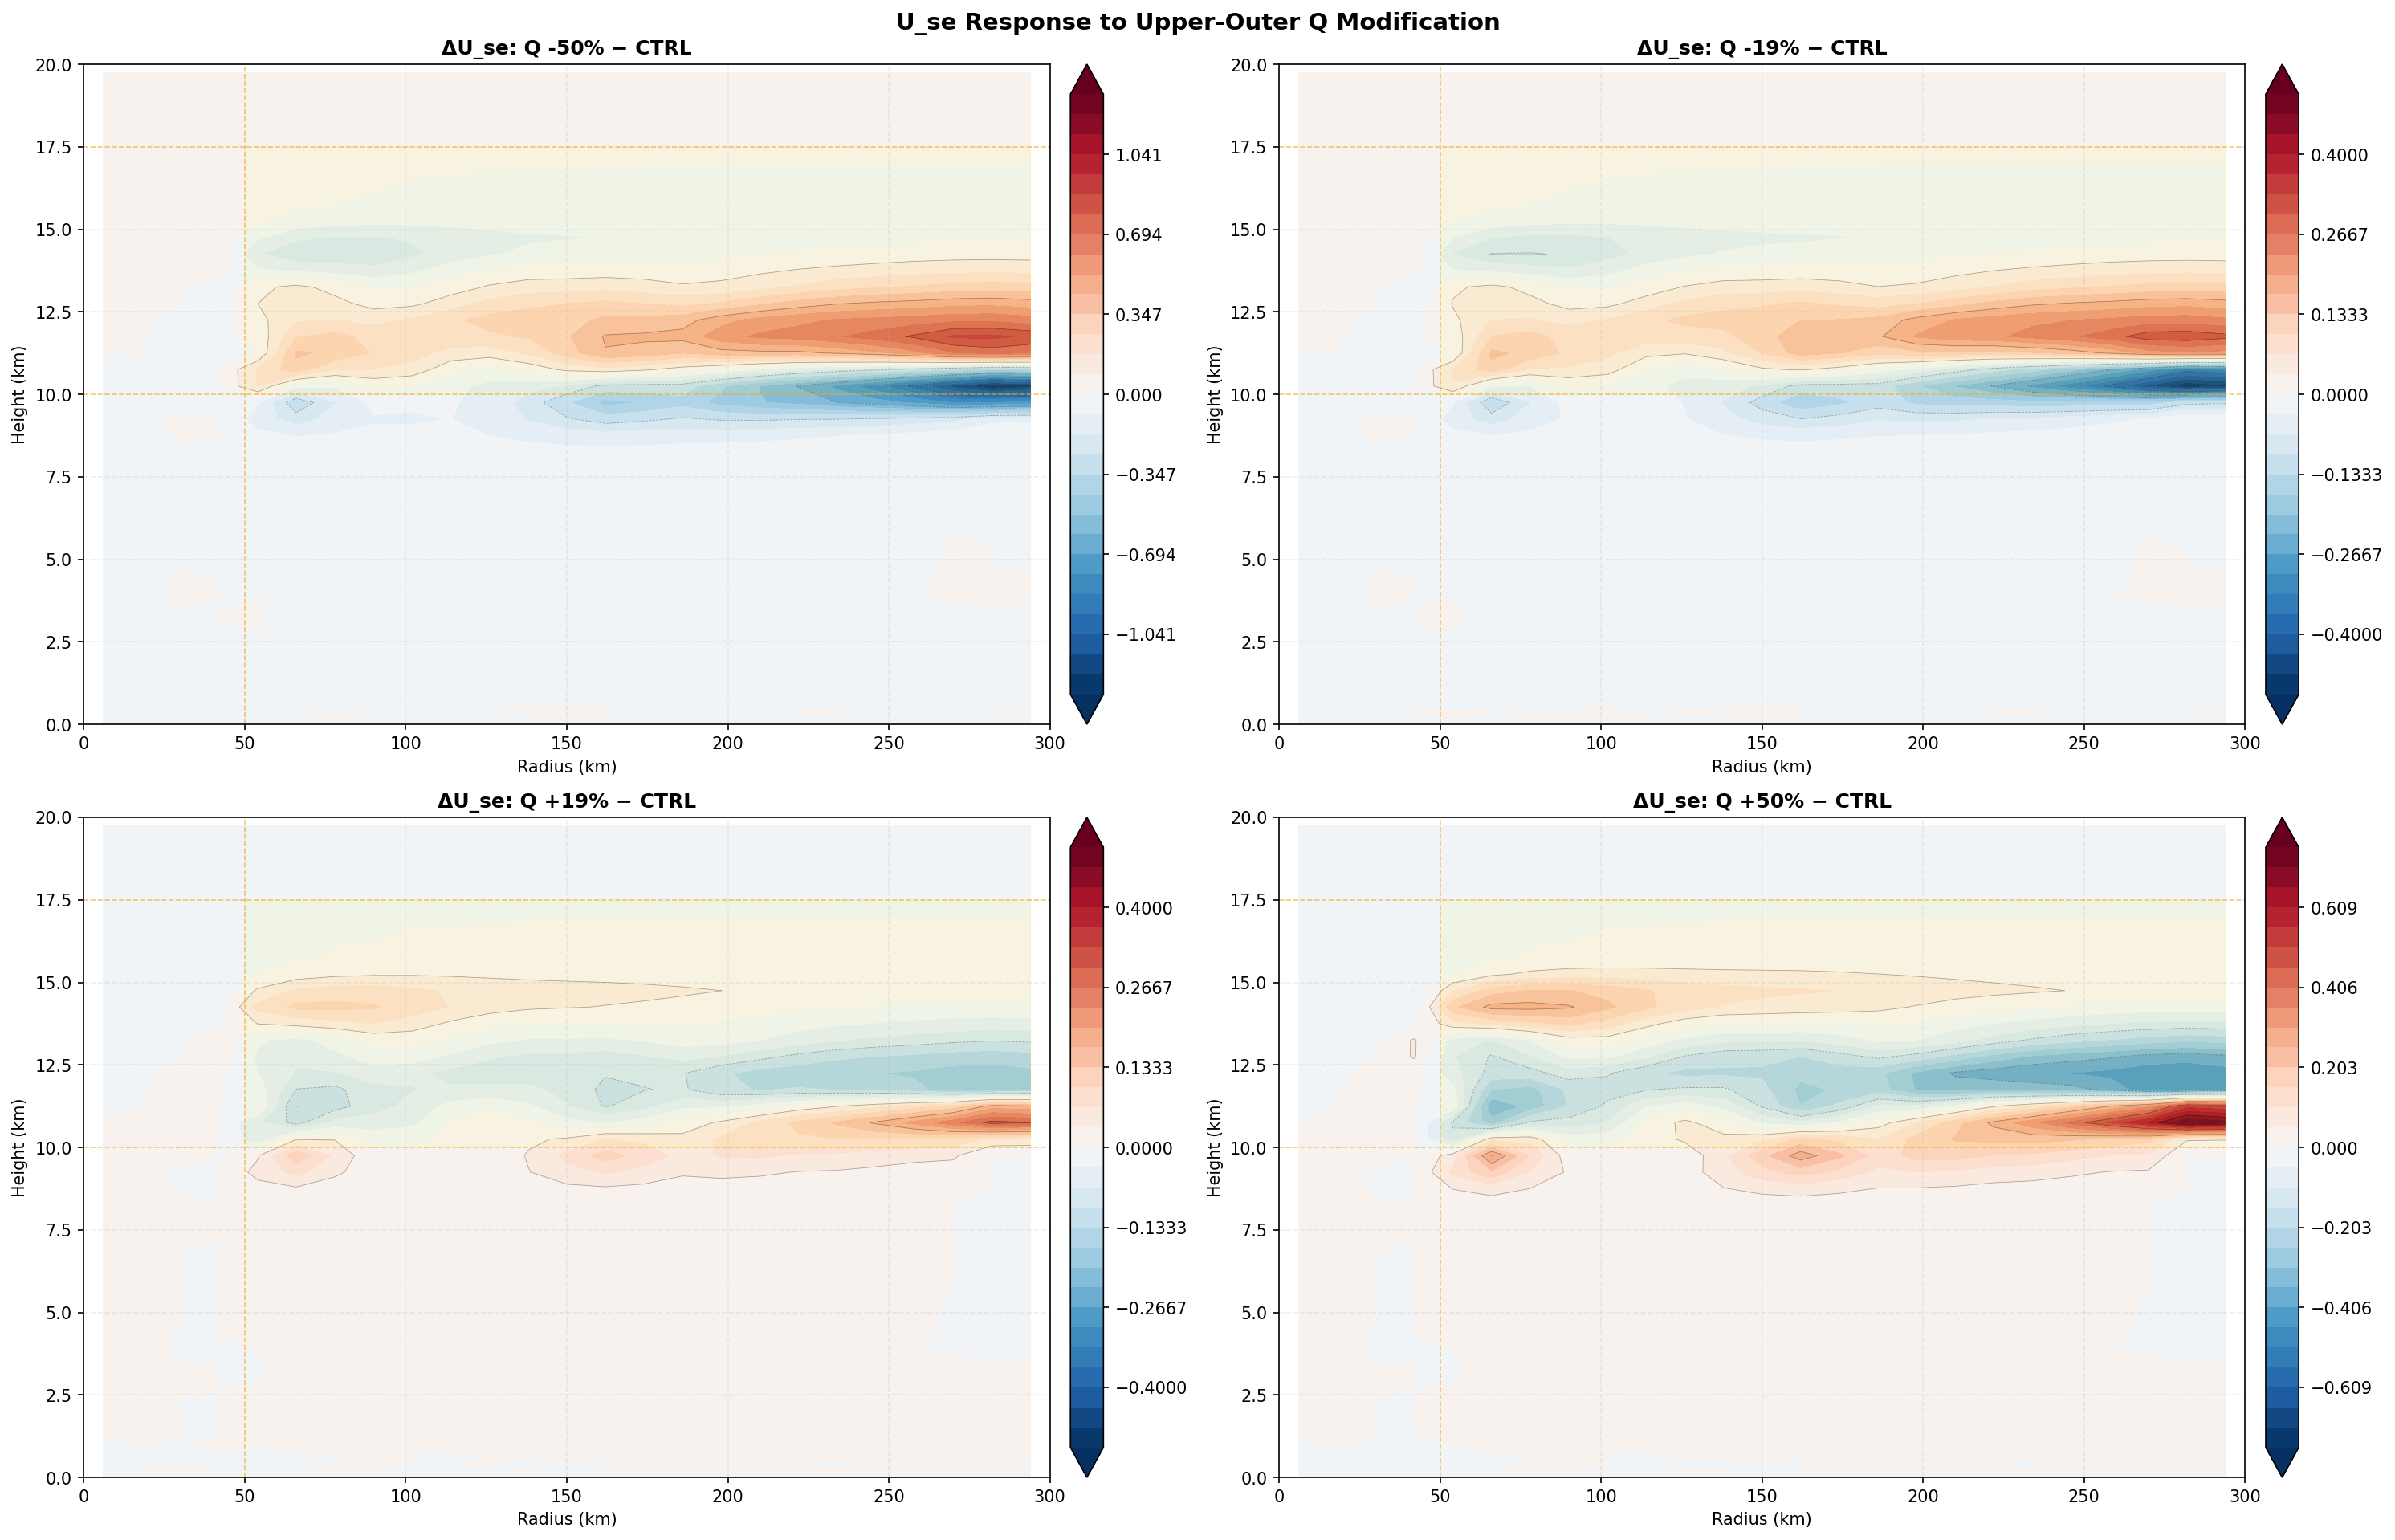

In [7]:
display(Image(filename='../output/figures/se_Q_sensitivity/se_dU_difference.png'))

---
## 3. 出流层 (z ≈ 15.0 km) 径向风廓线

黄色阴影: r > 50 km (Q 修改的径向范围)

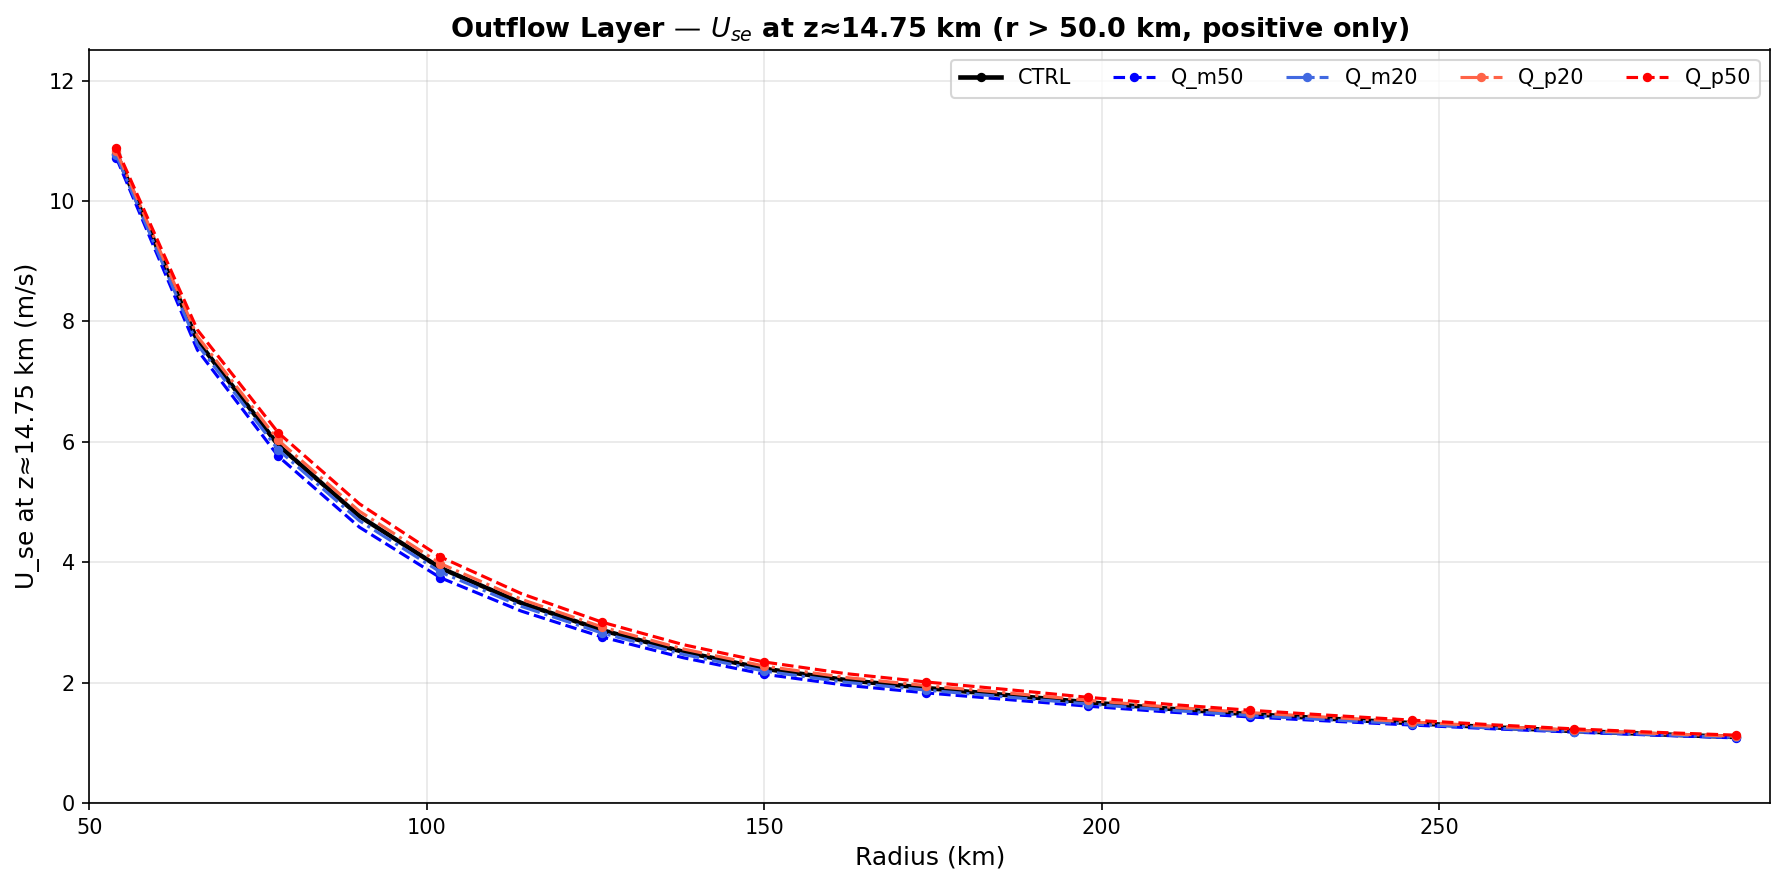

In [8]:
display(Image(filename='../output/figures/se_Q_sensitivity/se_outflow_profile.png'))

---
## 4. 入流层 (z ≈ 11.3 km) 径向风廓线

注意: z=11.3 km 位于 Q 修改区域内 (z ∈ [10, 17.5] km)

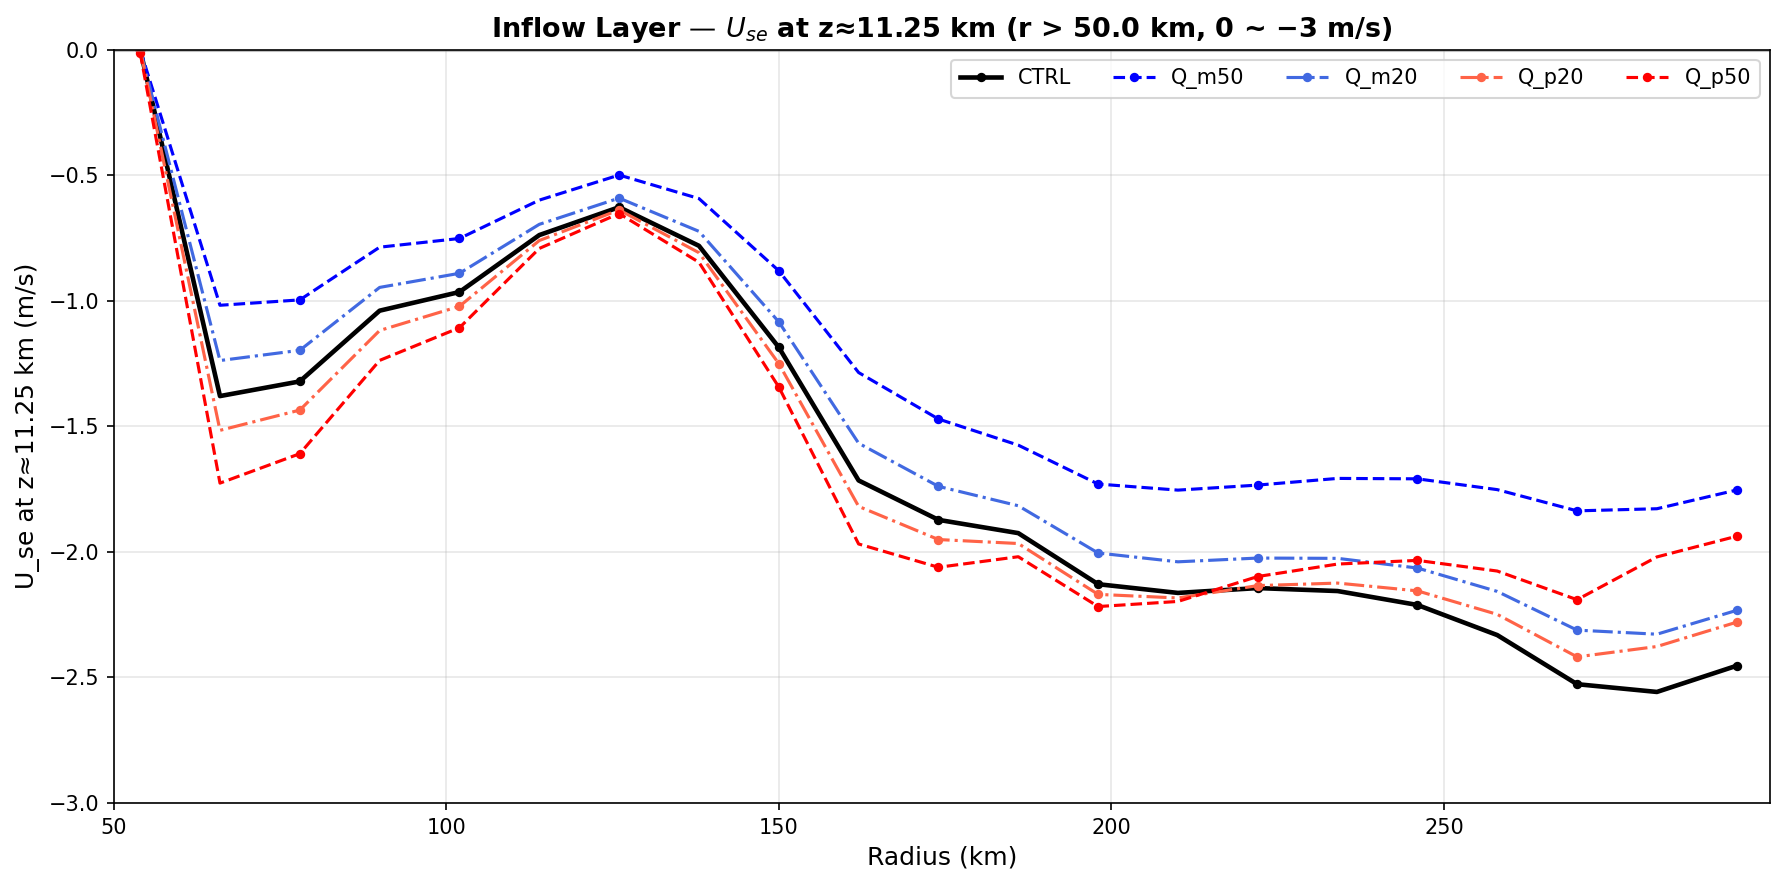

In [9]:
display(Image(filename='../output/figures/se_Q_sensitivity/se_inflow_profile.png'))

---
## 5. 定量分析与物理解释

In [6]:
import numpy as np

data = np.load('../output/figures/se_Q_sensitivity/se_sensitivity_results.npz')
r_km = data['r_km']
z_km = data['z_km']

labels = ['CTRL', 'Q_m50', 'Q_m20', 'Q_p20', 'Q_p50']
factors = {'CTRL': 1.0, 'Q_m50': 0.5, 'Q_m20': 0.8, 'Q_p20': 1.2, 'Q_p50': 1.5}

iz_out = np.argmin(np.abs(z_km - 15.0))
iz_in  = np.argmin(np.abs(z_km - 11.3))

print(f"出流层: z = {z_km[iz_out]:.3f} km")
print(f"入流层: z = {z_km[iz_in]:.3f} km")
print()

# 计算各半径处的灵敏度
r_check = [100, 150, 200]
print("=" * 80)
print(f"{'试验':<10} {'出流层 U_se (m/s)':>40} {'入流层 U_se (m/s)':>30}")
print(f"{'':10}", end="")
for rc in r_check:
    print(f"r={rc:4d}km  ", end="")
print("  ", end="")
for rc in r_check:
    print(f"r={rc:4d}km  ", end="")
print()
print("-" * 80)

for label in labels:
    u_out = data[f'{label}_U_se'][iz_out, :]
    u_in  = data[f'{label}_U_se'][iz_in, :]
    print(f"{label:<10}", end="")
    for rc in r_check:
        ir = np.argmin(np.abs(r_km - rc))
        print(f"{u_out[ir]:10.4f}  ", end="")
    print("  ", end="")
    for rc in r_check:
        ir = np.argmin(np.abs(r_km - rc))
        print(f"{u_in[ir]:10.4f}  ", end="")
    print()

print()
print("=" * 80)
print("相对变化 (% vs CTRL):")
print(f"{'试验':<10} {'出流层  Δ%':>40} {'入流层  Δ%':>30}")
print("-" * 80)

u_out_ctrl = data['CTRL_U_se'][iz_out, :]
u_in_ctrl  = data['CTRL_U_se'][iz_in, :]

for label in ['Q_m50', 'Q_m20', 'Q_p20', 'Q_p50']:
    u_out = data[f'{label}_U_se'][iz_out, :]
    u_in  = data[f'{label}_U_se'][iz_in, :]
    print(f"{label:<10}", end="")
    for rc in r_check:
        ir = np.argmin(np.abs(r_km - rc))
        dp = (u_out[ir] - u_out_ctrl[ir]) / abs(u_out_ctrl[ir]) * 100
        print(f"{dp:+9.2f}%  ", end="")
    print("  ", end="")
    for rc in r_check:
        ir = np.argmin(np.abs(r_km - rc))
        dp = (u_in[ir] - u_in_ctrl[ir]) / abs(u_in_ctrl[ir]) * 100
        print(f"{dp:+9.2f}%  ", end="")
    print()

出流层: z = 14.750 km
入流层: z = 11.250 km

试验                                   出流层 U_se (m/s)                 入流层 U_se (m/s)
          r= 100km  r= 150km  r= 200km    r= 100km  r= 150km  r= 200km  
--------------------------------------------------------------------------------
CTRL          3.9051      2.2313      1.6732       -0.9654     -1.1856     -2.1286  
Q_m50         3.7430      2.1402      1.6090       -0.7523     -0.8808     -1.7299  
Q_m20         3.8376      2.1924      1.6452       -0.8909     -1.0842     -2.0045  
Q_p20         3.9786      2.2760      1.7066       -1.0224     -1.2504     -2.1692  
Q_p50         4.0889      2.3431      1.7567       -1.1076     -1.3435     -2.2176  

相对变化 (% vs CTRL):
试验                                          出流层  Δ%                        入流层  Δ%
--------------------------------------------------------------------------------
Q_m50         -4.15%      -4.08%      -3.84%       +22.07%     +25.71%     +18.73%  
Q_m20         -1.73%      -1.74

---
## 5.5. 相对变化趋势图

**虚线 = 出流层 (z≈14.75 km) | 实线 = 入流层 (z≈11.25 km) | 颜色 = 不同半径**

CTRL (Q factor=1.0) 处为 0% 参考点。

In [ ]:
display(Image(filename='../output/figures/se_Q_sensitivity/se_sensitivity_trend.png'))

---
## 6. CTRL Q 热力场 (z = 10–17.5 km, r = 50–300 km)

非绝热加热率 Q 在修改区域内的分布。红=加热, 蓝=冷却。

In [ ]:
display(Image(filename='../output/figures/se_Q_sensitivity/se_Q_field.png'))

---
## 7. 方位角平均雷达回波 — 降水类型判断

黑色虚线: 35 dBZ (层云/对流分界线)。高层 (z>10km) 全部为层云降水 (dbz < 35 dBZ)。

In [ ]:
display(Image(filename='../output/figures/dbz_azimuthal_mean.png'))

### 物理解释

1. **出流层 (z≈14.75 km)**:
   - 增强上层外区加热 → 出流增强 (U_se ↑)
   - 减弱上层外区加热 → 出流减弱 (U_se ↓)
   - Q 增强 50% → 出流在 r=150km 处增加 ~5%
   - Q 减弱 50% → 出流在 r=150km 处减小 ~4%

2. **入流层 (z≈11.25 km)**:
   - 响应比出流层更强 (因 z=11.25 km 位于 Q 修改区域内)
   - 增强高层加热 → 低层入流增强 (质量补偿)
   - Q 增强 50% → 入流在 r=100km 处增强 ~15%
   - Q 减弱 50% → 入流在 r=100km 处减弱 ~22%
   - 入流层对 Q 减弱的响应比增强更显著 (非线性)

3. **物理机制**:
   - Q 加热 → 局地位温升高 → 通过热成风关系调整切向风 → 改变惯性稳定度
   - SE 方程中 Q 通过 $F_\text{thermal}$ 驱动次级环流
   - 上层外区加热增强 → 上升运动增强 → 出流层辐散增强 → 入流层补偿入流增强
   - 这是一个上下层耦合的次级环流响应，而非局地强迫

---
## 📁 汇总文件夹

所有图片和表格已汇总至：

```
output/figures/se_Q_sensitivity/summary/
├── README.md                     ← 完整说明 + 表格
├── Fig1_wind_comparison.png      ← 风场对比
├── Fig2_dU_difference.png        ← ΔU_se 差值图  
├── Fig3_outflow_profile.png      ← 出流层廓线 (r>50km, 仅正值)
├── Fig4_inflow_profile.png       ← 入流层廓线 (r>50km, 0~−3 m/s)
├── table_outflow.csv             ← 出流层数值表
├── table_inflow.csv              ← 入流层数值表
└── table_relative_change.csv     ← 相对变化表
```